In [3]:
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import train_test_split

from sklearn.metrics import fbeta_score



In [4]:
def load_data():
    data=np.load('embeddings_1.npy')
    data=np.concatenate((data, np.load('embeddings_2.npy')), axis=0)
    labels=[]
    for file_name in ['icd_codes_1.txt', 'icd_codes_2.txt']:
        with open(file_name) as file:
            for line in file:
                labels.append(line.strip().split(';'))
    multihot=MultiLabelBinarizer(sparse_output=True)
    labels=multihot.fit_transform(labels)
    return data, labels, multihot

X, y, multihot=load_data()

In [5]:
X.shape, y.shape

((198982, 1024), (198982, 1400))

In [22]:
y.sum(axis=0).argmin()

np.int64(646)

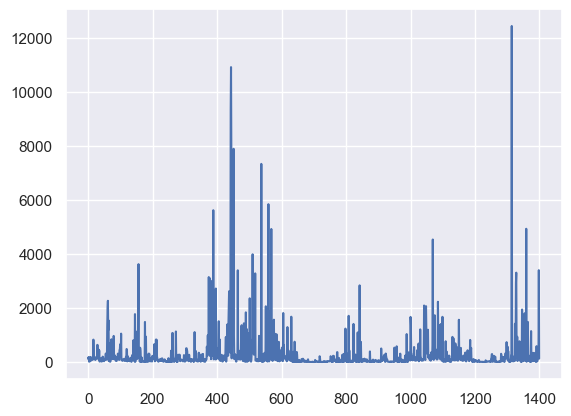

In [4]:
plt.plot(np.array(y.sum(axis=0))[0])

In [43]:
class MultiLogReg(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator):
        self.estimators=[]
        self.estimator=estimator
        self._is_fitted=False
        self.n_outputs=0
    
    def fit(self, X, y):
        self.estimators=[]
        self.n_outputs=y.shape[1]
        for i in range(self.n_outputs):
            new_estimator=clone(self.estimator)
            try:
                new_estimator.fit(X, y[:, i].toarray().flatten())
            except ValueError:
                pass
            self.estimators.append(new_estimator)
        self._is_fitted=True
        return self
    
    def predict(self, X):
        predictions=[]
        for i in range(len(self.estimators)):
            pred=None
            try:
                pred=self.estimators[i].predict(X)
            except AttributeError:
                pred=np.zeros(X.shape[0])
            predictions.append( sparse.csr_matrix(pred) )
        
        return sparse.vstack(predictions).T

    def __sklearn_is_fitted__(self):
        return self._is_fitted
        

In [6]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=0)

In [35]:
y_train.sum(axis=0).argmin()

np.int64(714)

In [46]:
clsf=MultiLogReg(LogisticRegression())
clsf.fit(X_train, y_train[:, :100])

MultiLogReg(estimator=LogisticRegression())

In [47]:
predictions=clsf.predict(X_train)
fbeta_score(y_train[:, :100], predictions, beta=2, average='micro')

np.float64(0.8102302044056361)

In [48]:
predictions=clsf.predict(X_test)
fbeta_score(y_test[:, :100], predictions, beta=2, average='micro')

np.float64(0.7697170855065592)

In [133]:
def raito(y, n):
    counts=np.unique_counts(y[:, n].toarray().flatten())[1]
    return counts[1]/counts[0]


In [5]:
from multiprocessing import cpu_count, Process

In [16]:
class MultiLogReg(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator):
        self.estimators=[]
        self.estimator=estimator
        self._is_fitted=False
        self.n_outputs=0
    
    # def fit_individual(self, X, y, estimator):
    #     print(id(X))
    #     try:
    #         estimator.fit(X, y)
    #     except ValueError:
    #         return

    def fit(self, X, y):
        print(self.fit.__name__)
        self.estimators=[]
        self.n_outputs=y.shape[1]
        processes=[]
        for i in range(self.n_outputs):
            new_estimator=clone(self.estimator)
            self.estimators.append(new_estimator)
            p=Process(target=fit_individual, args=(X, y[:, i].toarray().flatten(), new_estimator))
            processes.append(p)
            if __name__ == '__main__':
                print(1)
                p.start()
            # fit_individual(X, y[:, i].toarray().flatten(), new_estimator)
        for p in processes:
            if __name__ == '__main__':
                p.join()

        self._is_fitted=True
        return self
    
    def predict(self, X):
        predictions=[]
        for i in range(len(self.estimators)):
            pred=None
            try:
                pred=self.estimators[i].predict(X)
            except AttributeError:
                pred=np.zeros(X.shape[0])
            predictions.append( sparse.csr_matrix(pred) )
        
        return sparse.vstack(predictions).T

    def __sklearn_is_fitted__(self):
        return self._is_fitted

def fit_individual(X, y, estimator):
    print(id(X))
    try:
        estimator.fit(X, y)
    except ValueError:
        return
        

In [ ]:
clsf=MultiLogReg(LogisticRegression())
clsf.fit(X_train, y_train[:, :2])

fit
1


In [10]:
predictions=clsf.predict(X_train)
fbeta_score(y_train[:, :2], predictions, beta=2, average='micro')

np.float64(0.8180987202925045)

In [ ]:
from multiprocessing import Process
import os

def info(title):
    print(title)
    print('module name:', __name__)
    print('parent process:', os.getppid())
    print('process id:', os.getpid())

def f(name):
    info('function f')
    print('hello', name)

if __name__ == '__main__':
    info('main line')
    p = Process(target=f, args=('bob',))
    p.start()
    p.join()

main line
module name: __main__
parent process: 27384
process id: 28752
